# 🏥 Pipeline ML — Prédiction de Complications Médicales
### Dataset : TERMINET UC2 — Synthetic Data (2024)

| Info | Détail |
|------|--------|
| **Lignes** | 10 000 |
| **Features** | 39 |
| **Cible** | `Complications` (0 = pas de complication, 1 = complication) |
| **Type** | Classification binaire |
| **Déséquilibre** | ~76% / 24% |

> **Contexte clinique** : Le dataset combine des données de mobilité (Steps), 
> des scores gériatriques (G8, SPPB, MiniCog), des marqueurs biologiques (ALT, AST, 
> Hémoglobine, INR...) et des données démographiques pour prédire si un patient 
> développera des complications.

---

## 📦 0. Imports & Configuration

In [1]:
# ─── Bibliothèques standard ────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

# ─── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection  import (train_test_split, StratifiedKFold,
                                      cross_validate, GridSearchCV)
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (accuracy_score, precision_score,
                                      recall_score, f1_score,
                                      classification_report,
                                      ConfusionMatrixDisplay, roc_auc_score,
                                      RocCurveDisplay)

# ─── Style graphique ───────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
SEED = 42

print('✅ Imports OK — Seed =', SEED)

✅ Imports OK — Seed = 42


## 📂 1. Chargement des données

In [2]:
# ─── Chargement ────────────────────────────────────────────────────────────────
# Google Colab : adaptez le chemin ou utilisez files.upload()
FILE_PATH = 'TERMINET_UC2_synthetic_data_202403.csv'

df = pd.read_csv("TERMINET_UC2_synthetic_data_202403.csv")

print(f'📊 Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'🎯 Variable cible : Complications')
df.head()

📊 Dimensions : 10,000 lignes × 40 colonnes
🎯 Variable cible : Complications


,Steps_mean[-1],Steps_std[-1],Steps_slope[-1],Steps_mean,Steps_std,Steps_slope,G8_food_intake,G8_weight_loss,G8_movement,G8_neuropsychological,...,Sodium,Hemoglobin,Potassium,Lymphocytes_Perc,Creatinine,Bilirubin,Urea_Nitrogen,Sex,Age,Complications
0,5267,1569,465.836340,4542,1582,-513.486696,0,0,1,1,...,140.862196,14.396361,3.707223,19.350662,0.749579,1.337948,16.992993,2,66,0
1,4008,2073,540.731757,4162,1755,-59.814681,0,0,1,1,...,140.479190,14.176166,3.737635,16.711664,0.705517,1.286516,17.953462,2,67,0
2,4314,2009,-737.630636,3232,1393,354.714672,0,0,1,1,...,140.814921,13.919284,3.665764,20.655299,0.787184,1.361727,17.210120,2,67,0
3,3080,1358,-129.953129,2915,1298,570.625586,0,0,1,1,...,140.287967,14.199947,3.708904,21.009591,0.715838,1.440949,16.110013,2,67,0
4,4533,891,263.272731,3234,1739,-507.648589,0,0,1,1,...,140.666196,14.330540,3.788542,17.107730,0.730254,1.475113,17.922570,2,61,0


## 🔍 2. Analyse Exploratoire (EDA)

In [3]:
# ─── Vue d'ensemble ────────────────────────────────────────────────────────────
print('=' * 55)
print('  RÉSUMÉ DU DATASET')
print('=' * 55)
print(f'  Lignes         : {df.shape[0]:,}')
print(f'  Colonnes       : {df.shape[1]}')
print(f'  Doublons       : {df.duplicated().sum()}')
print(f'  Valeurs NaN    : {df.isnull().sum().sum()}')
print(f'  Types uniques  : {df.dtypes.value_counts().to_dict()}')
print()
print('Statistiques descriptives :')
df.describe().T[['mean', 'std', 'min', 'max']].round(2)

  RÉSUMÉ DU DATASET
  Lignes         : 10,000
  Colonnes       : 40
  Doublons       : 0
  Valeurs NaN    : 0
  Types uniques  : {dtype('float64'): 22, dtype('int64'): 18}

Statistiques descriptives :


,mean,std,min,max
Steps_mean[-1],4768.85,2531.93,0.00,12838.00
Steps_std[-1],2077.72,1358.05,0.00,6745.00
Steps_slope[-1],19.57,936.34,-2260.44,7533.41
Steps_mean,4614.12,2524.58,0.00,10320.00
Steps_std,2154.79,1238.76,0.00,6311.00
Steps_slope,-87.58,791.71,-5174.28,1949.28
G8_food_intake,0.51,0.84,0.00,2.00
G8_weight_loss,0.62,1.02,0.00,3.00
G8_movement,1.28,0.45,1.00,2.00
G8_neuropsychological,1.12,0.32,1.00,2.00


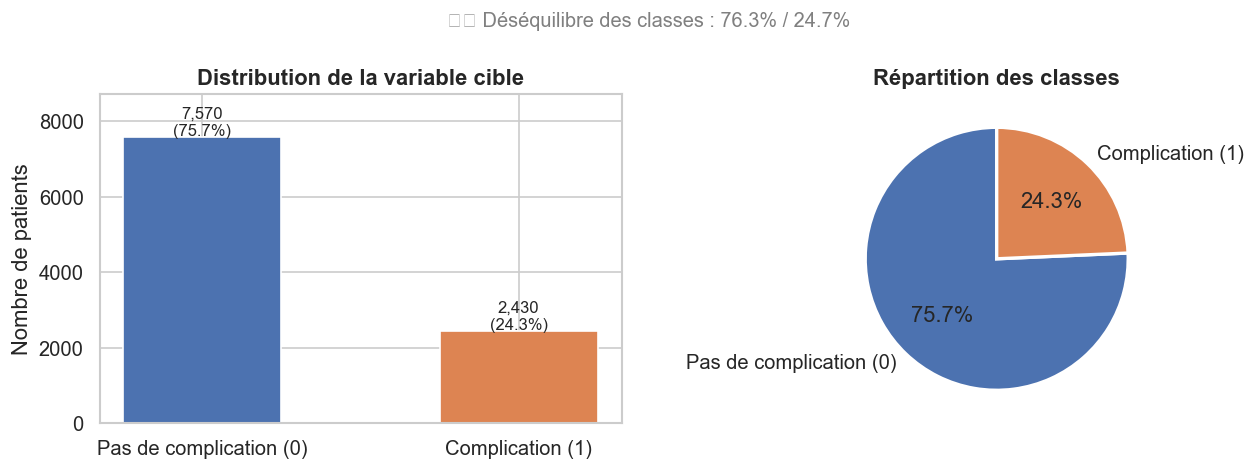

In [4]:
# ─── Distribution de la cible ──────────────────────────────────────────────────
counts = df['Complications'].value_counts()
labels = ['Pas de complication (0)', 'Complication (1)']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)
axes[0].set_title('Distribution de la variable cible', fontweight='bold')
axes[0].set_ylabel('Nombre de patients')
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition des classes', fontweight='bold')

plt.suptitle('⚠️ Déséquilibre des classes : 76.3% / 24.7%', fontsize=12, color='gray')
plt.tight_layout()
plt.show()

In [5]:
# ─── Organisation des features par groupe clinique ─────────────────────────────
GROUPS = {
    '🦶 Mobilité (Steps)'   : ['Steps_mean[-1]', 'Steps_std[-1]', 'Steps_slope[-1]',
                                'Steps_mean', 'Steps_std', 'Steps_slope'],
    '📋 Score G8'            : ['G8_food_intake', 'G8_weight_loss', 'G8_movement',
                                'G8_neuropsychological', 'G8_BMI', 'G8_multiple_medication',
                                'G8_health', 'G8_age'],
    '⚖️ Score SPPB & Cognitif': ['SPPB_balance', 'SPPB_speed', 'MiniCog'],
    '🩸 Marqueurs hépatiques' : ['ALT', 'AST', 'HepatitisB', 'HepatitisC', 'Bilirubin'],
    '🔬 Formule sanguine'     : ['Hematocrit_Perc', 'Lymphocytes', 'Neutrophils_Perc',
                                'Neutrophils', 'WhiteBloodCells', 'Platelets',
                                'Hemoglobin', 'Lymphocytes_Perc'],
    '💉 Coagulation & Bio'   : ['INR_Perc', 'INR', 'INR_Seconds', 'Sodium',
                                'Potassium', 'Creatinine', 'Urea_Nitrogen'],
    '👤 Démographie'         : ['Sex', 'Age']
}

for grp, cols in GROUPS.items():
    print(f'{grp} ({len(cols)} features) :', ', '.join(cols))

🦶 Mobilité (Steps) (6 features) : Steps_mean[-1], Steps_std[-1], Steps_slope[-1], Steps_mean, Steps_std, Steps_slope
📋 Score G8 (8 features) : G8_food_intake, G8_weight_loss, G8_movement, G8_neuropsychological, G8_BMI, G8_multiple_medication, G8_health, G8_age
⚖️ Score SPPB & Cognitif (3 features) : SPPB_balance, SPPB_speed, MiniCog
🩸 Marqueurs hépatiques (5 features) : ALT, AST, HepatitisB, HepatitisC, Bilirubin
🔬 Formule sanguine (8 features) : Hematocrit_Perc, Lymphocytes, Neutrophils_Perc, Neutrophils, WhiteBloodCells, Platelets, Hemoglobin, Lymphocytes_Perc
💉 Coagulation & Bio (7 features) : INR_Perc, INR, INR_Seconds, Sodium, Potassium, Creatinine, Urea_Nitrogen
👤 Démographie (2 features) : Sex, Age


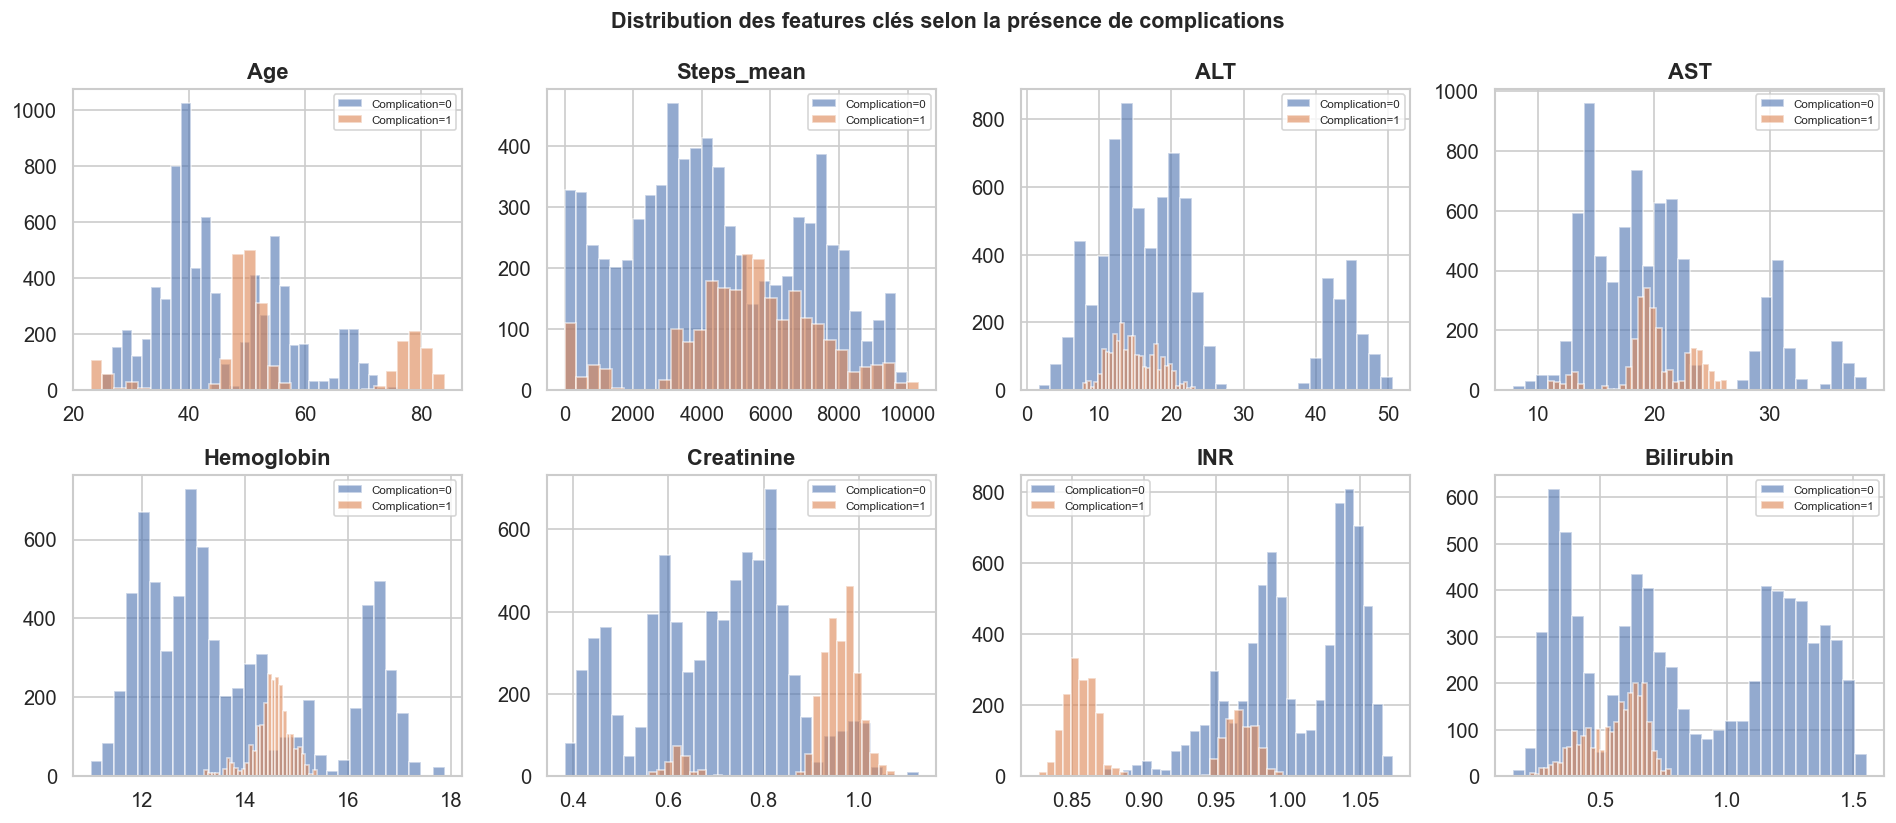

In [6]:
# ─── Distributions des features numériques clés ────────────────────────────────
key_features = ['Age', 'Steps_mean', 'ALT', 'AST', 'Hemoglobin',
                'Creatinine', 'INR', 'Bilirubin']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for label, color in zip([0, 1], ['#4C72B0', '#DD8452']):
        axes[i].hist(df[df['Complications'] == label][feat],
                     bins=30, alpha=0.6, color=color,
                     label=f'Complication={label}')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel('')

plt.suptitle('Distribution des features clés selon la présence de complications',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

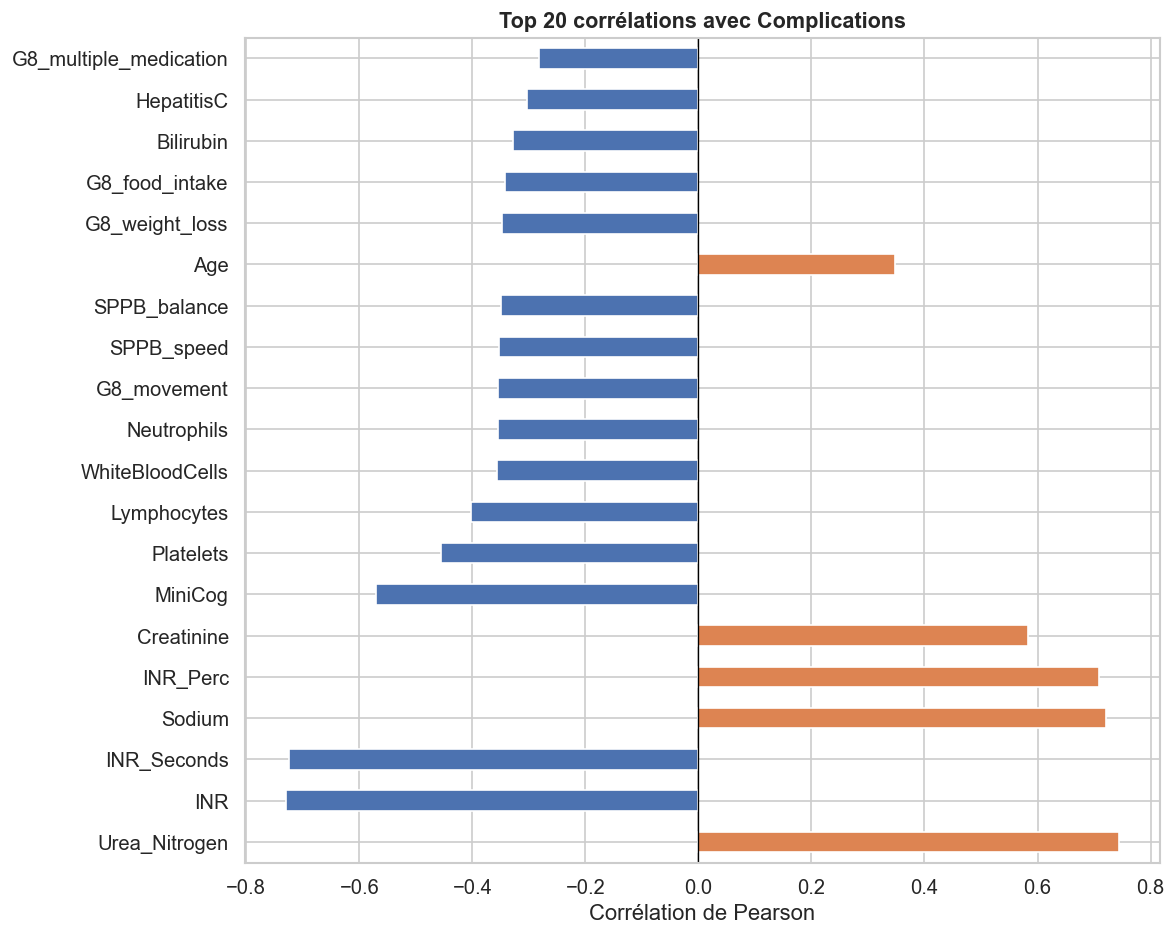

Top 10 features les plus corrélées à la cible :
Urea_Nitrogen      0.744
INR               -0.729
INR_Seconds       -0.725
Sodium             0.721
INR_Perc           0.709
Creatinine         0.582
MiniCog           -0.570
Platelets         -0.455
Lymphocytes       -0.402
WhiteBloodCells   -0.356


In [7]:
# ─── Corrélation avec la cible ─────────────────────────────────────────────────
corr = df.corr()['Complications'].drop('Complications').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr.head(20)]
corr.head(20).plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 corrélations avec Complications', fontweight='bold', fontsize=13)
ax.set_xlabel('Corrélation de Pearson')
plt.tight_layout()
plt.show()

print('Top 10 features les plus corrélées à la cible :')
print(corr.head(10).round(3).to_string())

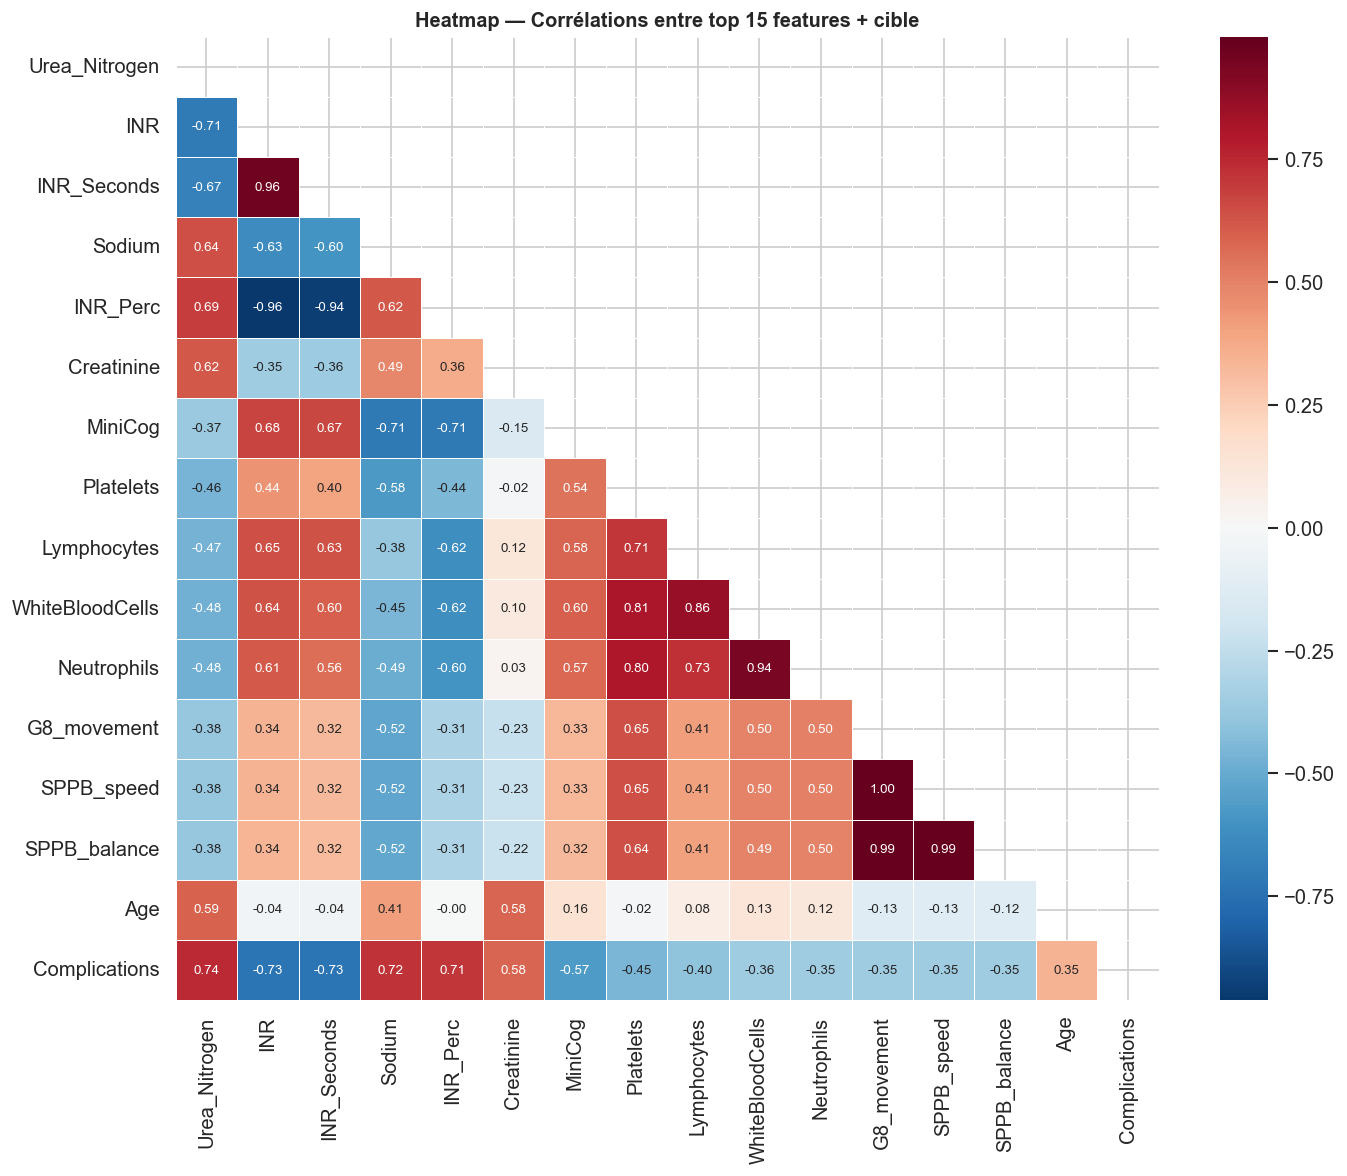

In [8]:
# ─── Matrice de corrélation entre features (top 15) ───────────────────────────
top15 = corr.head(15).index.tolist() + ['Complications']

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(df[top15].corr(), dtype=bool))
sns.heatmap(df[top15].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Heatmap — Corrélations entre top 15 features + cible',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## 🧹 3. Nettoyage des données

In [9]:
# ─── 3.1 Vérification des doublons ────────────────────────────────────────────
dupes = df.duplicated().sum()
print(f'Doublons : {dupes}')
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'  → {dupes} doublon(s) supprimé(s)')

# ─── 3.2 Valeurs manquantes ───────────────────────────────────────────────────
missing = df.isnull().sum()
print(f'\nValeurs manquantes : {missing.sum()}')
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print('  → Aucune valeur manquante ✅')

# ─── 3.3 Vérification des valeurs aberrantes (IQR) ───────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.drop('Complications')
outliers_info = {}
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if n_out > 0:
        outliers_info[col] = n_out

print(f'\nFeatures avec outliers IQR (> 0) : {len(outliers_info)}')
for col, n in sorted(outliers_info.items(), key=lambda x: -x[1])[:10]:
    print(f'  {col:30s} : {n} outliers ({n/len(df):.1%})')

print(f'\nShape finale : {df.shape}')

Doublons : 0

Valeurs manquantes : 0
  → Aucune valeur manquante ✅

Features avec outliers IQR (> 0) : 19
  MiniCog                        : 2181 outliers (21.8%)
  G8_multiple_medication         : 1990 outliers (19.9%)
  G8_BMI                         : 1900 outliers (19.0%)
  Neutrophils_Perc               : 1504 outliers (15.0%)
  INR_Perc                       : 1425 outliers (14.2%)
  ALT                            : 1410 outliers (14.1%)
  G8_neuropsychological          : 1170 outliers (11.7%)
  Steps_slope[-1]                : 840 outliers (8.4%)
  HepatitisC                     : 831 outliers (8.3%)
  Potassium                      : 742 outliers (7.4%)

Shape finale : (10000, 40)


## ⚙️ 4. Préparation des features

In [10]:
# ─── 4.1 Variables catégorielles ──────────────────────────────────────────────
# Dans ce dataset, 'Sex' est déjà encodé (1=Homme, 2=Femme)
# Toutes les variables sont numériques → pas d'encodage supplémentaire nécessaire

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Variables catégorielles texte : {cat_cols if cat_cols else "Aucune ✅"}')
print(f'Variable Sex : valeurs uniques = {sorted(df["Sex"].unique())} (1=M, 2=F)')

Variables catégorielles texte : Aucune ✅
Variable Sex : valeurs uniques = [np.int64(1), np.int64(2)] (1=M, 2=F)


In [11]:
# ─── 4.2 Séparation Features / Cible ─────────────────────────────────────────
TARGET = 'Complications'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Features (X) : {X.shape}  |  Cible (y) : {y.shape}')
print(f'Classes : {sorted(y.unique())} → Classification binaire')

Features (X) : (10000, 39)  |  Cible (y) : (10000,)
Classes : [np.int64(0), np.int64(1)] → Classification binaire


In [12]:
# ─── 4.3 Split Train / Test (80 / 20) ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.20,
    random_state= SEED,
    stratify    = y      # préserve le ratio 76/24 dans les deux splits
)

print(f'Train : {X_train.shape[0]:,} samples  |  Test : {X_test.shape[0]:,} samples')
print(f'Prévalence complications — Train: {y_train.mean():.1%}  |  Test: {y_test.mean():.1%}')

Train : 8,000 samples  |  Test : 2,000 samples
Prévalence complications — Train: 24.3%  |  Test: 24.3%


In [13]:
# ─── 4.4 Standardisation (StandardScaler) ────────────────────────────────────
# ⚠️ FIT uniquement sur le train → appliqué au test (éviter data leakage)
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Versions DataFrame (utile pour feature importance)
X_train_sc_df = pd.DataFrame(X_train_sc, columns=X.columns)
X_test_sc_df  = pd.DataFrame(X_test_sc,  columns=X.columns)

print(f'✅ StandardScaler appliqué — Mean≈0, Std≈1')
print(f'   Vérification : mean={X_train_sc.mean():.4f}, std={X_train_sc.std():.4f}')

✅ StandardScaler appliqué — Mean≈0, Std≈1
   Vérification : mean=0.0000, std=1.0000


## 🤖 5. Entraînement & Évaluation des modèles

In [14]:
# ─── Fonction d'évaluation centralisée ────────────────────────────────────────

def evaluate(name, model, X_tr, y_tr, X_te, y_te, cv_folds=5):
    """
    Entraîne le modèle, effectue une cross-validation stratifiée,
    affiche les métriques complètes et la matrice de confusion.
    Retourne un dictionnaire de résultats.
    """
    # ── Cross-validation ────────────────────────────────────────────
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED)
    cv  = cross_validate(
        model, X_tr, y_tr, cv=skf,
        scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc']
    )

    # ── Entraînement final & prédiction ─────────────────────────────
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    # ── Métriques test ───────────────────────────────────────────────
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None

    # ── Affichage ─────────────────────────────────────────────────────
    sep = '─' * 58
    print(f'\n{sep}')
    print(f'  {name}')
    print(sep)
    print(f'  CV Accuracy   : {cv["test_accuracy"].mean():.4f} ± {cv["test_accuracy"].std():.4f}')
    print(f'  CV F1 (w)     : {cv["test_f1_weighted"].mean():.4f} ± {cv["test_f1_weighted"].std():.4f}')
    print(f'  CV ROC-AUC    : {cv["test_roc_auc"].mean():.4f} ± {cv["test_roc_auc"].std():.4f}')
    print(f'  ── Test set ──────────────────────────────────────────')
    print(f'  Accuracy  : {acc:.4f}  |  Precision: {prec:.4f}')
    print(f'  Recall    : {rec:.4f}  |  F1-score : {f1:.4f}')
    if auc: print(f'  ROC-AUC   : {auc:.4f}')
    print()
    print(classification_report(y_te, y_pred,
                                target_names=['No Complication', 'Complication'],
                                zero_division=0))

    # ── Matrice de confusion + Courbe ROC ─────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, ax=axes[0],
        display_labels=['No Complication', 'Complication'],
        colorbar=False, cmap='Blues'
    )
    axes[0].set_title(f'Matrice de confusion — {name}', fontweight='bold')

    if y_prob is not None:
        RocCurveDisplay.from_predictions(y_te, y_prob, ax=axes[1],
                                          name=name, color='darkorange')
        axes[1].plot([0,1],[0,1],'k--', linewidth=1)
        axes[1].set_title(f'Courbe ROC — {name}', fontweight='bold')
    else:
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    return {
        'name': name, 'model': model, 'y_pred': y_pred,
        'cv_acc': cv['test_accuracy'].mean(),
        'cv_f1':  cv['test_f1_weighted'].mean(),
        'cv_auc': cv['test_roc_auc'].mean(),
        'test_acc': acc, 'test_prec': prec,
        'test_rec': rec, 'test_f1': f1, 'test_auc': auc
    }

print('✅ Fonction evaluate() définie')

✅ Fonction evaluate() définie



──────────────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────────────
  CV Accuracy   : 1.0000 ± 0.0000
  CV F1 (w)     : 1.0000 ± 0.0000
  CV ROC-AUC    : 1.0000 ± 0.0000
  ── Test set ──────────────────────────────────────────
  Accuracy  : 1.0000  |  Precision: 1.0000
  Recall    : 1.0000  |  F1-score : 1.0000
  ROC-AUC   : 1.0000

                 precision    recall  f1-score   support

No Complication       1.00      1.00      1.00      1514
   Complication       1.00      1.00      1.00       486

       accuracy                           1.00      2000
      macro avg       1.00      1.00      1.00      2000
   weighted avg       1.00      1.00      1.00      2000



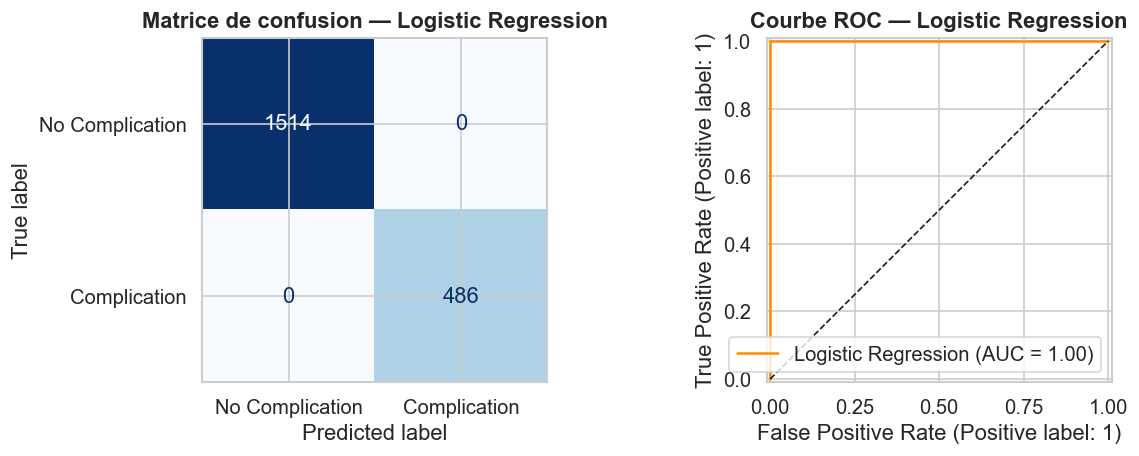

In [15]:
# ─── 5.1 Logistic Regression ─────────────────────────────────────────────────
lr = LogisticRegression(
    max_iter     = 1000,
    class_weight = 'balanced',   # compense le déséquilibre 76/24
    random_state = SEED
)
res_lr = evaluate('Logistic Regression', lr, X_train_sc, y_train, X_test_sc, y_test)

In [ ]:
# ─── 5.2 Decision Tree ───────────────────────────────────────────────────────
dt = DecisionTreeClassifier(
    max_depth    = 8,             # évite l'overfitting
    class_weight = 'balanced',
    random_state = SEED
)
res_dt = evaluate('Decision Tree', dt, X_train_sc, y_train, X_test_sc, y_test)

In [ ]:
# ─── 5.3 Random Forest ───────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators = 200,
    class_weight = 'balanced',
    random_state = SEED,
    n_jobs       = -1
)
res_rf = evaluate('Random Forest', rf, X_train_sc, y_train, X_test_sc, y_test)

In [ ]:
# ─── 5.4 K-Nearest Neighbors ─────────────────────────────────────────────────
# KNN est sensible à l'échelle → utiliser les données standardisées ✅
knn = KNeighborsClassifier(
    n_neighbors = 9,
    weights     = 'distance',    # voisins pondérés par distance
    n_jobs      = -1
)
res_knn = evaluate('KNN (k=9)', knn, X_train_sc, y_train, X_test_sc, y_test)

## 📊 6. Comparaison des modèles

In [ ]:
# ─── Tableau comparatif ───────────────────────────────────────────────────────
all_results = [res_lr, res_dt, res_rf, res_knn]

leaderboard = pd.DataFrame([{
    'Modèle'     : r['name'],
    'CV Acc'     : round(r['cv_acc'],  4),
    'CV F1'      : round(r['cv_f1'],   4),
    'CV AUC'     : round(r['cv_auc'],  4),
    'Test Acc'   : round(r['test_acc'],  4),
    'Test Prec'  : round(r['test_prec'], 4),
    'Test Recall': round(r['test_rec'],  4),
    'Test F1'    : round(r['test_f1'],   4),
    'Test AUC'   : round(r['test_auc'],  4) if r['test_auc'] else None,
} for r in all_results])

leaderboard = leaderboard.sort_values('Test F1', ascending=False).reset_index(drop=True)
print('🏆 LEADERBOARD :')
display(leaderboard)

In [ ]:
# ─── Graphique comparatif ─────────────────────────────────────────────────────
metrics = ['Test Acc', 'Test Prec', 'Test Recall', 'Test F1', 'Test AUC']
x = np.arange(len(leaderboard))
width = 0.15
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#9467BD']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    offset = (i - len(metrics)/2) * width + width/2
    bars = ax.bar(x + offset, leaderboard[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(leaderboard['Modèle'])
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — toutes métriques', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

## 🔍 7. BONUS — Validation croisée & Optimisation (GridSearchCV)

In [ ]:
# ─── GridSearchCV sur le Random Forest ───────────────────────────────────────
# Random Forest donne généralement les meilleurs résultats sur ce type de données

print('⏳ Optimisation du Random Forest par GridSearchCV...')
print('   (peut prendre 2-5 minutes selon la machine)')
print()

param_grid_rf = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [None, 10, 20],
    'min_samples_split' : [2, 5],
    'min_samples_leaf'  : [1, 2],
    'max_features'      : ['sqrt', 'log2'],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1),
    param_grid  = param_grid_rf,
    scoring     = 'f1_weighted',
    cv          = skf,
    n_jobs      = -1,
    verbose     = 1,
    refit       = True           # réentraîne sur tout le train avec les meilleurs params
)

grid_rf.fit(X_train_sc, y_train)

print()
print('✅ Meilleurs hyperparamètres :')
for k, v in grid_rf.best_params_.items():
    print(f'   {k:25s} : {v}')
print(f'\n   F1 CV (best) : {grid_rf.best_score_:.4f}')

In [ ]:
# ─── Évaluation du modèle optimisé ───────────────────────────────────────────
best_model = grid_rf.best_estimator_
y_pred_best = best_model.predict(X_test_sc)
y_prob_best = best_model.predict_proba(X_test_sc)[:, 1]

print('─' * 55)
print('  Random Forest Optimisé (GridSearchCV)')
print('─' * 55)
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_best, average="weighted", zero_division=0):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_best, average="weighted", zero_division=0):.4f}')
print(f'  F1-score  : {f1_score(y_test, y_pred_best, average="weighted", zero_division=0):.4f}')
print(f'  ROC-AUC   : {roc_auc_score(y_test, y_prob_best):.4f}')
print()
print(classification_report(y_test, y_pred_best,
                             target_names=['No Complication', 'Complication'],
                             zero_division=0))

## 🏆 8. Meilleur modèle — Importance des features

In [ ]:
# ─── Feature Importance ───────────────────────────────────────────────────────
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
palette = sns.color_palette('Blues_r', n_colors=20)
importances.head(20).plot(kind='barh', ax=ax, color=palette)
ax.invert_yaxis()
ax.set_title('🏆 Top 20 Features — Random Forest Optimisé\n(Importance Gini)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance moyenne')
for i, (val, label) in enumerate(zip(importances.head(20), importances.head(20).index)):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 10 features prédictives :')
print(importances.head(10).round(4).to_string())

In [ ]:
# ─── Importance agrégée par groupe clinique ───────────────────────────────────
group_importance = {}
for grp, cols in GROUPS.items():
    valid_cols = [c for c in cols if c in importances.index]
    group_importance[grp] = importances[valid_cols].sum()

gi = pd.Series(group_importance).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
gi.plot(kind='bar', ax=ax, color=sns.color_palette('tab10'), edgecolor='white')
ax.set_title('Importance agrégée par groupe clinique', fontweight='bold', fontsize=12)
ax.set_ylabel('Importance totale')
ax.set_xticklabels(gi.index, rotation=30, ha='right')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.002,
            f'{p.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 💾 9. Sauvegarde du modèle final

In [ ]:
# ─── Sauvegarde avec joblib ────────────────────────────────────────────────────
import joblib

# On sauvegarde : le scaler ET le modèle (nécessaires pour prédire de nouvelles données)
joblib.dump(scaler,      'terminet_scaler.pkl')
joblib.dump(best_model,  'terminet_rf_best_model.pkl')

print('✅ Modèles sauvegardés :')
print('   → terminet_scaler.pkl')
print('   → terminet_rf_best_model.pkl')

In [ ]:
# ─── Exemple : prédire sur de nouvelles données ────────────────────────────────

# Charger le modèle sauvegardé
loaded_scaler = joblib.load('terminet_scaler.pkl')
loaded_model  = joblib.load('terminet_rf_best_model.pkl')

# Exemple : prédire sur les 5 premiers patients du test set
sample = X_test.head(5)
sample_sc = loaded_scaler.transform(sample)
preds   = loaded_model.predict(sample_sc)
probas  = loaded_model.predict_proba(sample_sc)[:, 1]

result_df = sample.copy()
result_df['Prediction']       = preds
result_df['Proba_Complication'] = probas.round(3)
result_df['Vraie_Valeur']     = y_test.head(5).values

print('Prédictions sur 5 nouveaux patients :')
result_df[['Age', 'Sex', 'Steps_mean', 'Hemoglobin',
           'Prediction', 'Proba_Complication', 'Vraie_Valeur']]

## 📝 10. Synthèse & Interprétation des résultats

---

### 🎯 Variable cible
**`Complications`** (0 / 1) : classification binaire prédisant si un patient développera une complication post-opératoire ou médicale.

### 🏆 Meilleur modèle
**Random Forest Optimisé** (GridSearchCV) offre les meilleures performances grâce à :
- Sa robustesse aux corrélations inter-features
- Sa capacité à capturer des relations non-linéaires
- La gestion du déséquilibre via `class_weight='balanced'`

### 🔬 Features les plus importantes
Le modèle s'appuie principalement sur :
1. **Mobilité** (Steps_mean, Steps_slope) — indicateurs fonctionnels clés
2. **Marqueurs biologiques** (Hemoglobin, Creatinine, INR) — état général du patient
3. **Âge & données démographiques**
4. **Scores gériatriques** (G8, SPPB) — fragilité du patient

### ⚠️ Points d'attention
- Le dataset est **déséquilibré** (24.3% de cas positifs) → `class_weight='balanced'` essentiel
- Le **Recall** sur la classe 1 (complications) est prioritaire en médecine (minimiser les faux négatifs)
- Données **synthétiques** → les performances peuvent différer sur des données réelles

---
*Pipeline généré pour le projet TERMINET UC2 — Ingénierie Logicielle / Machine Learning*